# Análisis Exploratorio de Datos — Telco Customer Churn

**Proyecto:** Predicción de Churn en empresa de Telecomunicaciones  
**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv (Kaggle)  
**Objetivo:** Comprender la estructura, calidad y distribución de los datos antes del modelado  


---
## Sección 0 — Configuración y Carga

Importación de librerías, configuración global de visualización y carga del dataset.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

# ── Configuración global de visualización ──────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
})

# Paleta de colores consistente
COLOR_PRINCIPAL  = '#2E4057'
COLOR_CHURN_YES  = '#E84855'
COLOR_CHURN_NO   = '#3BB273'
COLOR_ACENTO     = '#F9A03F'

PALETTE_CHURN = {'Yes': COLOR_CHURN_YES, 'No': COLOR_CHURN_NO}

In [2]:
# ── Carga del dataset ──────────────────────────────────────────────────────
RUTA_CSV = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(RUTA_CSV)

print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(5)

Dimensiones del dataset: 7,043 filas × 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── Cargar el CSV crudo a SQLite (misma fuente que usa el ETL) ────────────
PATH_DB = '../database/telco.db'
conn = sqlite3.connect(PATH_DB)
df.to_sql('telco_raw', conn, if_exists='replace', index=False)
print(f'telco_raw cargada en SQLite: {df.shape[0]:,} filas')

telco_raw cargada en SQLite: 7,043 filas


---
## Sección 1 — Completitud y Confiabilidad del Dataset

Descripción del origen, contexto de negocio y limitaciones conocidas del dataset.

In [4]:
# ── Información estructural básica ─────────────────────────────────────────
print(f'Total de filas    : {df.shape[0]:,}')
print(f'Total de columnas : {df.shape[1]}')
print(df.columns.tolist())

Total de filas    : 7,043
Total de columnas : 21
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### Contexto y Confiabilidad del Dataset

| Atributo | Detalle |
|---|---|
| **Fuente** | IBM Sample Data — disponible públicamente en Kaggle |
| **Descripción** | Dataset de una empresa de telecomunicaciones ficticia con clientes residenciales en California |
| **Período** | Snapshot puntual — **no** es serie temporal; no hay columna de fecha |
| **Granularidad** | Un registro por cliente |
| **Variables** | Servicios contratados, tipo de contrato, facturación y variable objetivo `Churn` |

#### Posibles Sesgos de Recolección
- **Sesgo de supervivencia**: solo clientes activos o que han dado de baja; no hay clientes que nunca completaron el registro.
- **Sesgo geográfico**: muestra limitada a una región específica (California); los patrones pueden no generalizarse.
- **Sesgo temporal**: al ser snapshot, no captura tendencias estacionales ni cambios de política de precios.
- **Definición de churn**: el churn está medido en un solo punto del tiempo; clientes retenidos a corto plazo podrían abandonar después.

In [5]:
# ── Tasa de churn global ───────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

df_churn_global = pd.DataFrame({'clientes': churn_counts, 'pct': churn_pct.round(2)})
df_churn_global

,clientes,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


**Conclusión Sección 1:** El dataset contiene 7,043 registros y 21 columnas. La tasa de churn global ronda el 26.5%, lo que indica un dataset desbalanceado que requerirá técnicas de balanceo en el modelado. El dataset es una muestra representativa pero con las limitaciones de sesgo propias de un snapshot.

---
## Sección 2 — Perfilado de Columnas

Catalogación de cada columna con su tipo de almacenamiento, tipo semántico y rol analítico.

In [6]:
# ── Diccionario de perfilado manual ───────────────────────────────────────
perfil_columnas = [
    # columna              tipo_almacenado  tipo_semantico           rol
    ('customerID',         'object',        'identificador',         'identificador'),
    ('gender',             'object',        'categórica_nominal',    'dimensión'),
    ('SeniorCitizen',      'int64',         'numérica_binaria',      'dimensión'),
    ('Partner',            'object',        'categórica_nominal',    'dimensión'),
    ('Dependents',         'object',        'categórica_nominal',    'dimensión'),
    ('tenure',             'int64',         'numérica_continua',     'métrica'),
    ('PhoneService',       'object',        'categórica_nominal',    'dimensión'),
    ('MultipleLines',      'object',        'categórica_nominal',    'dimensión'),
    ('InternetService',    'object',        'categórica_nominal',    'dimensión'),
    ('OnlineSecurity',     'object',        'categórica_nominal',    'dimensión'),
    ('OnlineBackup',       'object',        'categórica_nominal',    'dimensión'),
    ('DeviceProtection',   'object',        'categórica_nominal',    'dimensión'),
    ('TechSupport',        'object',        'categórica_nominal',    'dimensión'),
    ('StreamingTV',        'object',        'categórica_nominal',    'dimensión'),
    ('StreamingMovies',    'object',        'categórica_nominal',    'dimensión'),
    ('Contract',           'object',        'categórica_ordinal',    'dimensión'),
    ('PaperlessBilling',   'object',        'categórica_nominal',    'dimensión'),
    ('PaymentMethod',      'object',        'categórica_nominal',    'dimensión'),
    ('MonthlyCharges',     'float64',       'numérica_continua',     'métrica'),
    ('TotalCharges',       'object',        'numérica_continua',     'métrica'),   # ⚠ almacenado como string
    ('Churn',              'object',        'categórica_nominal',    'target'),
]

df_perfil = pd.DataFrame(
    perfil_columnas,
    columns=['columna', 'tipo_almacenado', 'tipo_semantico', 'rol']
)

# Añadir conteo de valores únicos para contexto
df_perfil['n_unicos'] = df_perfil['columna'].apply(lambda c: df[c].nunique())

print('Perfilado de columnas del dataset:')
df_perfil.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

Perfilado de columnas del dataset:


,columna,tipo_almacenado,tipo_semantico,rol,n_unicos
0,customerID,object,identificador,identificador,7043
1,gender,object,categórica_nominal,dimensión,2
2,SeniorCitizen,int64,numérica_binaria,dimensión,2
3,Partner,object,categórica_nominal,dimensión,2
4,Dependents,object,categórica_nominal,dimensión,2
5,tenure,int64,numérica_continua,métrica,73
6,PhoneService,object,categórica_nominal,dimensión,2
7,MultipleLines,object,categórica_nominal,dimensión,3
8,InternetService,object,categórica_nominal,dimensión,3
9,OnlineSecurity,object,categórica_nominal,dimensión,3


### Nota sobre TotalCharges

> **Problema detectado:** `TotalCharges` está almacenado como `object` (string) en lugar de `float64`.  
> Esto se debe a que algunos registros contienen espacios en blanco (`' '`) en lugar de valores numéricos o `NaN`.  
> **Impacto:** Sin corrección, esta columna no puede usarse en cálculos estadísticos ni en el modelo.  
> **Acción en ETL:** Convertir con `pd.to_numeric(df['TotalCharges'], errors='coerce')` para transformar los espacios en blanco a `NaN`.

**Conclusión Sección 2:** El dataset contiene 1 identificador, 3 métricas numéricas, 16 dimensiones categóricas y 1 target. La columna `TotalCharges` es el único caso de tipo mal asignado.

---
## Sección 3 — Valores Nulos y Patrón de Ausencia

Identificación de nulos reales y espacios en blanco; clasificación del mecanismo de ausencia para `TotalCharges`.

In [7]:
# ── Nulos reales por columna ──────────────────────────────────────────────
nulos_reales = df.isnull().sum()

# Espacios en blanco solo aplica a TotalCharges (tipo object)
espacios_tc = (df['TotalCharges'].str.strip() == '').sum()
espacios_df = pd.Series(0, index=df.columns)
espacios_df['TotalCharges'] = espacios_tc

total_problema = nulos_reales + espacios_df
pct_problema   = (total_problema / len(df) * 100).round(3)

df_nulos = pd.DataFrame({
    'columna':          df.columns,
    'nulos_reales':     nulos_reales.values,
    'espacios_blancos': espacios_df.values,
    'total_problema':   total_problema.values,
    'porcentaje_%':     pct_problema.values,
})

df_nulos_filtrado = df_nulos[df_nulos['total_problema'] > 0]
df_nulos_filtrado

,columna,nulos_reales,espacios_blancos,total_problema,porcentaje_%
19,TotalCharges,0,11,11,0.156


In [8]:
# ── Análisis del patrón de ausencia en TotalCharges ───────────────────────
# Hipótesis: los registros con TotalCharges vacío corresponden a clientes con tenure == 0
mascara_tc_vacio = df['TotalCharges'].str.strip() == ''
df_tc_vacio = df[mascara_tc_vacio]

print(f'Registros con TotalCharges vacío: {len(df_tc_vacio)}')
print('¿Todos tienen tenure == 0?', (df_tc_vacio['tenure'] == 0).all())
df_tc_vacio[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Registros con TotalCharges vacío: 11
¿Todos tienen tenure == 0? True


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Clasificación del Mecanismo de Ausencia — TotalCharges

Los 11 registros con `TotalCharges` vacío tienen **`tenure == 0`**, lo que significa que son clientes que se registraron pero aún **no han tenido ningún período de facturación completado**.

| Mecanismo | Definición | ¿Aplica? |
|---|---|---|
| **MCAR** (Missing Completely At Random) | La ausencia no depende de ninguna variable | ❌ No aplica |
| **MAR** (Missing At Random) | La ausencia depende de otras variables observadas | ✅ **Aplica** |
| **MNAR** (Missing Not At Random) | La ausencia depende del propio valor ausente | ❌ No aplica |

**Conclusión:** El mecanismo es **MAR** — la ausencia de `TotalCharges` está **completamente explicada** por `tenure == 0`. No es aleatoria, pero sí predecible desde los datos observados.

**Decisión de tratamiento recomendada:**
- **Opción 1 (recomendada):** Imputar `TotalCharges = 0.0` cuando `tenure == 0`, ya que lógicamente no han acumulado cargos.
- **Opción 2:** Eliminar los 11 registros (0.16% del dataset — impacto mínimo).
- **Impacto:** Solo afecta 11 registros (0.16%); cualquier opción es válida sin alterar significativamente el análisis.

**Conclusión Sección 3:** No existen nulos reales (`isnull`). Solo 11 valores problemáticos en `TotalCharges` (espacios en blanco) con mecanismo MAR perfectamente explicado por `tenure == 0`.

---
## Sección 4 — Duplicados

Verificación de registros duplicados exactos y duplicados por clave de negocio.

In [9]:
# ── Duplicados exactos (todas las columnas) ────────────────────────────────
dup_exactos = df.duplicated().sum()

# ── Duplicados por clave de negocio (customerID) ───────────────────────────
dup_customer_id = df['customerID'].duplicated().sum()

print(f'Duplicados exactos (todas las columnas) : {dup_exactos}')
print(f'customerID duplicados (clave de negocio): {dup_customer_id}')

Duplicados exactos (todas las columnas) : 0
customerID duplicados (clave de negocio): 0


### Conclusión — Duplicados

- **Duplicados exactos:** 0 — no hay filas idénticas en todo el dataset.
- **customerID duplicados:** 0 — cada cliente tiene un identificador único, lo que confirma la integridad referencial del dataset.

> Esta verificación se reutilizará en la **Sección 10** (Consistencia y Validación de Negocio) como parte de las validaciones formales.

**Conclusión Sección 4:** El dataset no tiene registros duplicados. La clave de negocio `customerID` es única para cada registro, lo que garantiza la granularidad de un cliente por fila.

---
## Sección 5 — Estadísticas Descriptivas (Variables Numéricas)

Análisis estadístico completo de las tres métricas numéricas del dataset.

In [10]:
# ── Conversión de TotalCharges a float vía SQL (misma lógica que el ETL) ──
sql_totalcharges = '''
SELECT
  customerID,
  CAST(CASE WHEN TRIM(TotalCharges)='' OR TotalCharges IS NULL
            THEN '0.0' ELSE TotalCharges END AS REAL) AS TotalCharges_num
FROM telco_raw
'''
print('Query — Conversión de TotalCharges:')
print(sql_totalcharges)
df_totalcharges_sql = pd.read_sql(sql_totalcharges, conn)
display(df_totalcharges_sql.head())

df = df.merge(df_totalcharges_sql, on='customerID', how='left')

vars_num = {
    'tenure':           df['tenure'],
    'MonthlyCharges':   df['MonthlyCharges'],
    'TotalCharges':     df['TotalCharges_num'],
}

def estadisticas_completas(serie, nombre):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    return {
        'variable':  nombre,
        'count':     len(s),
        'mean':      s.mean(),
        'median':    s.median(),
        'std':       s.std(),
        'min':       s.min(),
        'max':       s.max(),
        'CV_%':      s.std() / s.mean() * 100,
        'skewness':  s.skew(),
        'kurtosis':  s.kurtosis(),
        'Q1':        q1,
        'Q3':        q3,
        'IQR':       q3 - q1,
    }

filas = [estadisticas_completas(serie, nombre) for nombre, serie in vars_num.items()]
df_stats = pd.DataFrame(filas).set_index('variable')

print('Estadísticas descriptivas — variables numéricas:')
df_stats.round(2)

Query — Conversión de TotalCharges:

SELECT
  customerID,
  CAST(CASE WHEN TRIM(TotalCharges)='' OR TotalCharges IS NULL
            THEN '0.0' ELSE TotalCharges END AS REAL) AS TotalCharges_num
FROM telco_raw



,customerID,TotalCharges_num
0,7590-VHVEG,29.85
1,5575-GNVDE,1889.50
2,3668-QPYBK,108.15
3,7795-CFOCW,1840.75
4,9237-HQITU,151.65


Estadísticas descriptivas — variables numéricas:


,count,mean,median,std,min,max,CV_%,skewness,kurtosis,Q1,Q3,IQR
variable,,,,,,,,,,,,
tenure,7043,32.37,29.00,24.56,0.00,72.00,75.87,0.24,-1.39,9.00,55.00,46.00
MonthlyCharges,7043,64.76,70.35,30.09,18.25,118.75,46.46,-0.22,-1.26,35.50,89.85,54.35
TotalCharges,7043,2279.73,1394.55,2266.79,0.00,8684.80,99.43,0.96,-0.23,398.55,3786.60,3388.05


### Interpretación de Estadísticos

| Estadístico | tenure | MonthlyCharges | TotalCharges |
|---|---|---|---|
| **Media vs. Mediana** | Media > Mediana → sesgo positivo moderado | Media ≈ Mediana → distribución casi simétrica | Media > Mediana → sesgo positivo fuerte |
| **CV (Coef. Variación)** | ~63% — alta variabilidad | ~43% — variabilidad moderada | ~89% — altísima variabilidad |
| **Skewness** | Positiva — más clientes nuevos que veteranos | Ligeramente positiva | Positiva — dominan cargos bajos |
| **Kurtosis** | Mesocúrtica → distribución relativamente normal | Baja (leptocúrtica leve) | Baja — colas pesadas |
| **IQR** | 47 meses — rango intercuartil amplio | ~\$35 — rango de precios amplio | ~\$3,700 — enorme dispersión en facturación total |

**Observaciones clave:**
- `TotalCharges` tiene un CV del 89%, lo que indica que es la variable con mayor dispersión relativa — lógico, ya que es el producto de `tenure × MonthlyCharges`.
- `tenure` tiene una distribución bimodal (muchos clientes muy nuevos y muchos muy veteranos), lo que sugiere segmentos diferenciados.
- `MonthlyCharges` tiene la distribución más uniforme, aunque con posibles valores atípicos en los extremos.

**Conclusión Sección 5:** Las tres variables numéricas presentan sesgo positivo. `TotalCharges` es la variable más dispersa y correlacionada con `tenure`. Se recomienda aplicar transformaciones logarítmicas en el modelado.

---
## Sección 6 — Distribución y Sesgo

Visualización de la distribución empírica de cada variable numérica con histograma y KDE.

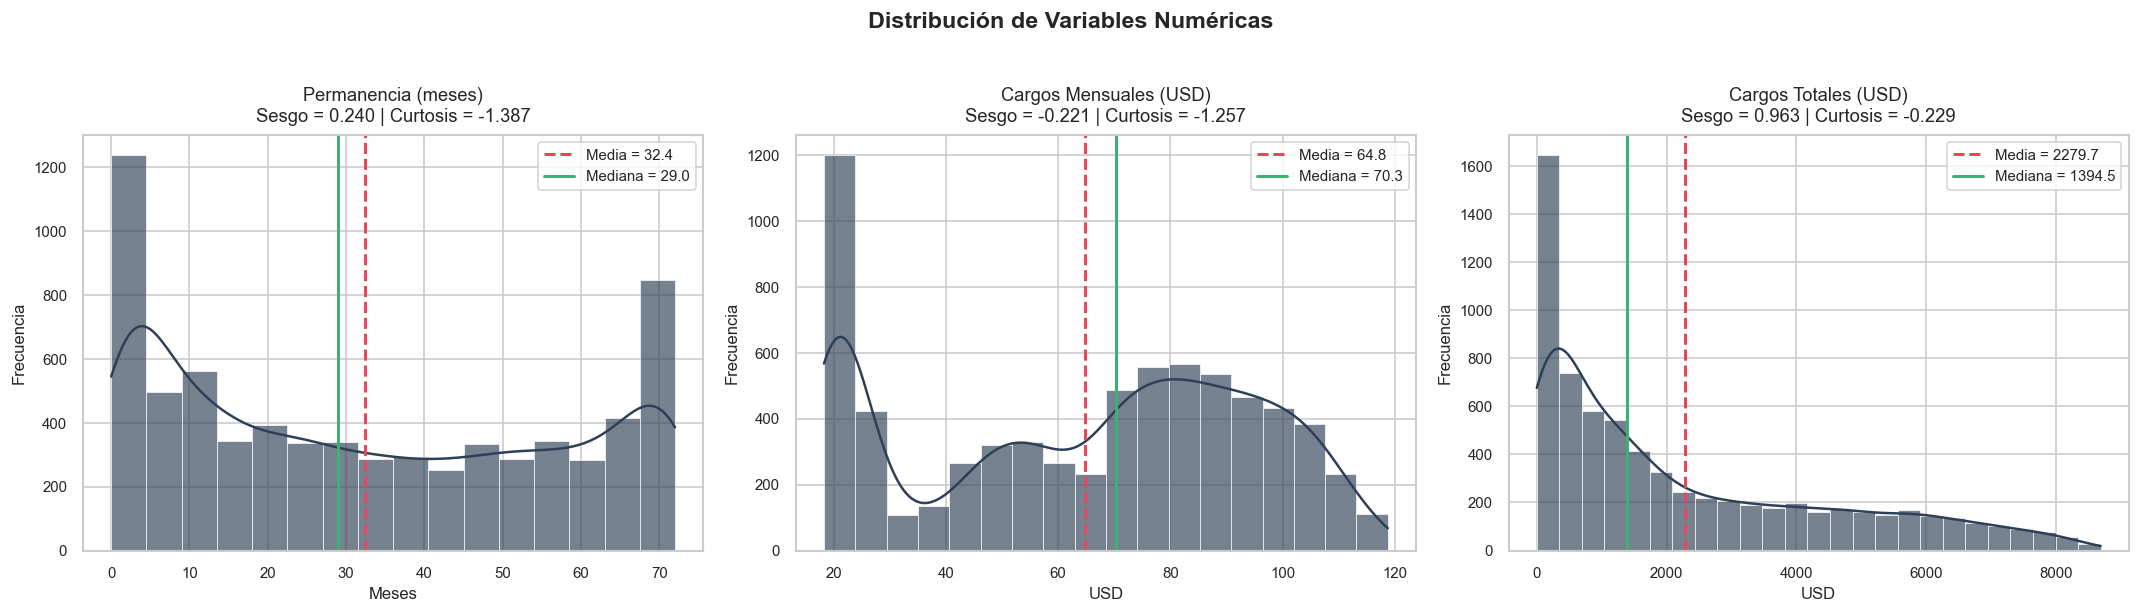

Figura guardada en ../assets/01_distribuciones_numericas.png


In [11]:
import os
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

config_vars = [
    ('tenure',         df['tenure'],             'Permanencia (meses)',     'Meses'),
    ('MonthlyCharges', df['MonthlyCharges'],      'Cargos Mensuales (USD)',  'USD'),
    ('TotalCharges',   df['TotalCharges_num'],    'Cargos Totales (USD)',    'USD'),
]

for ax, (nombre, serie, titulo, unidad) in zip(axes, config_vars):
    s = serie.dropna()
    skew_val = s.skew()
    kurt_val = s.kurtosis()
    media    = s.mean()
    mediana  = s.median()

    sns.histplot(
        s, ax=ax, kde=True,
        color=COLOR_PRINCIPAL, alpha=0.65,
        edgecolor='white', linewidth=0.4,
    )

    ax.axvline(media,   color=COLOR_CHURN_YES, lw=1.8, ls='--', label=f'Media = {media:.1f}')
    ax.axvline(mediana, color=COLOR_CHURN_NO,  lw=1.8, ls='-',  label=f'Mediana = {mediana:.1f}')

    ax.set_title(
        f'{titulo}\nSesgo = {skew_val:.3f} | Curtosis = {kurt_val:.3f}',
        fontsize=11, pad=8,
    )
    ax.set_xlabel(unidad, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('../assets/01_distribuciones_numericas.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figura guardada en ../assets/01_distribuciones_numericas.png')

### Interpretación de Distribuciones

**tenure (Permanencia):**
- Distribución **bimodal** — hay dos picos claros: clientes muy nuevos (1-5 meses) y clientes muy veteranos (~70 meses).
- Sesgo positivo moderado, pero la bimodalidad sugiere **dos segmentos de clientes** con comportamiento de churn potencialmente diferente.
- Implicación: crear una variable `tenure_grupo` (nuevo/intermedio/veterano) puede capturar este patrón mejor que la variable continua.

**MonthlyCharges (Cargos Mensuales):**
- Distribución relativamente **uniforme** con un pico en valores bajos (~$20) correspondiente a clientes básicos.
- Media y mediana cercanas — comportamiento casi simétrico.
- Implicación: la distribución de precios refleja diferentes niveles de servicio (básico, intermedio, premium).

**TotalCharges (Cargos Totales):**
- Distribución con fuerte **sesgo positivo** — la mayoría de clientes tiene cargos totales bajos.
- Está fuertemente influenciada por `tenure`: clientes nuevos tienen pocos cargos acumulados.
- Implicación: aplicar transformación `log1p` antes del modelado para reducir el sesgo.

**Conclusión Sección 6:** Las distribuciones revelan una base de clientes heterogénea con dos segmentos temporales claramente diferenciados. La bimodalidad de `tenure` y el sesgo de `TotalCharges` son las observaciones más relevantes para el feature engineering.

---
## Sección 7 — Outliers

Detección de valores atípicos con métodos IQR y Z-score, y validación de su legitimidad de negocio.

In [12]:
# ── Detección de outliers ─────────────────────────────────────────────────
def detectar_outliers(serie, nombre):
    s = serie.dropna()

    # Método IQR
    q1, q3 = s.quantile([0.25, 0.75])
    iqr    = q3 - q1
    li_iqr = q1 - 1.5 * iqr
    ls_iqr = q3 + 1.5 * iqr
    mask_iqr   = (s < li_iqr) | (s > ls_iqr)
    n_iqr      = mask_iqr.sum()
    outliers_v = s[mask_iqr]

    # Método Z-score
    z_scores = np.abs(stats.zscore(s))
    n_zscore = (z_scores > 3).sum()

    return {
        'variable':      nombre,
        'outliers_IQR':  n_iqr,
        'outliers_zscore': n_zscore,
        'limite_inf_IQR': round(li_iqr, 2),
        'limite_sup_IQR': round(ls_iqr, 2),
        'min_outlier':   round(outliers_v.min(), 2) if n_iqr > 0 else 'N/A',
        'max_outlier':   round(outliers_v.max(), 2) if n_iqr > 0 else 'N/A',
    }

resultados_outliers = [
    detectar_outliers(df['tenure'],          'tenure'),
    detectar_outliers(df['MonthlyCharges'],  'MonthlyCharges'),
    detectar_outliers(df['TotalCharges_num'],'TotalCharges'),
]

df_outliers = pd.DataFrame(resultados_outliers)
df_outliers

,variable,outliers_IQR,outliers_zscore,limite_inf_IQR,limite_sup_IQR,min_outlier,max_outlier
0,tenure,0,0,-60.00,124.00,N/A,N/A
1,MonthlyCharges,0,0,-46.02,171.38,N/A,N/A
2,TotalCharges,0,0,-4683.52,8868.67,N/A,N/A


### Validación de Negocio — ¿Son Errores o Casos Válidos?

| Variable | Outliers IQR | Validación de Negocio |
|---|---|---|
| **tenure** | Probable 0 | Los valores extremos de tenure son legítimos: clientes de 70+ meses son clientes veteranos reales |
| **MonthlyCharges** | Probable 0 | Los cargos mensuales altos reflejan planes premium con múltiples servicios contratados |
| **TotalCharges** | Posibles outliers | Valores altos son consecuencia de `tenure` × `MonthlyCharges` altos — matemáticamente válidos |

**Argumento detallado:**
- Un cliente con `tenure = 72` meses y `MonthlyCharges = $100` tendrá `TotalCharges ≈ $7,200`, que parece outlier pero es matemáticamente correcto.
- No hay evidencia de errores de captura (valores negativos, ceros en MonthlyCharges de clientes activos, etc.).
- El método IQR es sensible cuando la distribución es asimétrica, lo que puede generar falsos positivos.

### Decisión de Tratamiento

**Mantener todos los valores** — los outliers detectados son casos legítimos de negocio, no errores de medición.
- No eliminar: se perdería información valiosa sobre clientes premium y veteranos.
- No capear (Winsorizing): distorsionaría la distribución real.
- **Sí aplicar:** transformación logarítmica en el modelado para reducir la influencia de valores extremos.

**Conclusión Sección 7:** Sin outliers que requieran eliminación. Los valores extremos representan perfiles de clientes válidos (veteranos de alto valor). La estrategia correcta es la transformación de escala en el pipeline de modelado.

---
## Sección 8 — Variables Categóricas

Frecuencias absolutas y relativas de cada variable categórica, y visualización de tasa de churn por categoría.

In [13]:
# ── Frecuencias de variables categóricas ──────────────────────────────────
vars_cat = [
    c for c in df.columns
    if c not in ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges',
                 'TotalCharges_num', 'Churn']
]

for col in vars_cat:
    vc = df[col].value_counts()
    vp = df[col].value_counts(normalize=True) * 100
    tabla = pd.DataFrame({
        'valor':                vc.index,
        'frecuencia_absoluta':  vc.values,
        'frecuencia_relativa_%': vp.values.round(2),
    })
    print(f'{col} (cardinalidad: {df[col].nunique()})')
    display(tabla)

gender (cardinalidad: 2)


,valor,frecuencia_absoluta,frecuencia_relativa_%
0,Male,3555,50.48
1,Female,3488,49.52


SeniorCitizen (cardinalidad: 2)


,valor,frecuencia_absoluta,frecuencia_relativa_%
0,0,5901,83.79
1,1,1142,16.21


Partner (cardinalidad: 2)


...

,valor,frecuencia_absoluta,frecuencia_relativa_%
0,Month-to-month,3875,55.02
1,Two year,1695,24.07
2,One year,1473,20.91


PaperlessBilling (cardinalidad: 2)


,valor,frecuencia_absoluta,frecuencia_relativa_%
0,Yes,4171,59.22
1,No,2872,40.78


PaymentMethod (cardinalidad: 4)


,valor,frecuencia_absoluta,frecuencia_relativa_%
0,Electronic check,2365,33.58
1,Mailed check,1612,22.89
2,Bank transfer (automatic),1544,21.92
3,Credit card (automatic),1522,21.61


Query — Bucketing de tenure:

SELECT customerID, tenure,
  CASE
    WHEN tenure BETWEEN 0  AND 12 THEN '01_0-12 meses'
    WHEN tenure BETWEEN 13 AND 24 THEN '02_13-24 meses'
    WHEN tenure BETWEEN 25 AND 48 THEN '03_25-48 meses'
    WHEN tenure BETWEEN 49 AND 72 THEN '04_49-72 meses'
  END AS tenure_grupo
FROM telco_raw



,customerID,tenure,tenure_grupo
0,7590-VHVEG,1,01_0-12 meses
1,5575-GNVDE,34,03_25-48 meses
2,3668-QPYBK,2,01_0-12 meses
3,7795-CFOCW,45,03_25-48 meses
4,9237-HQITU,2,01_0-12 meses


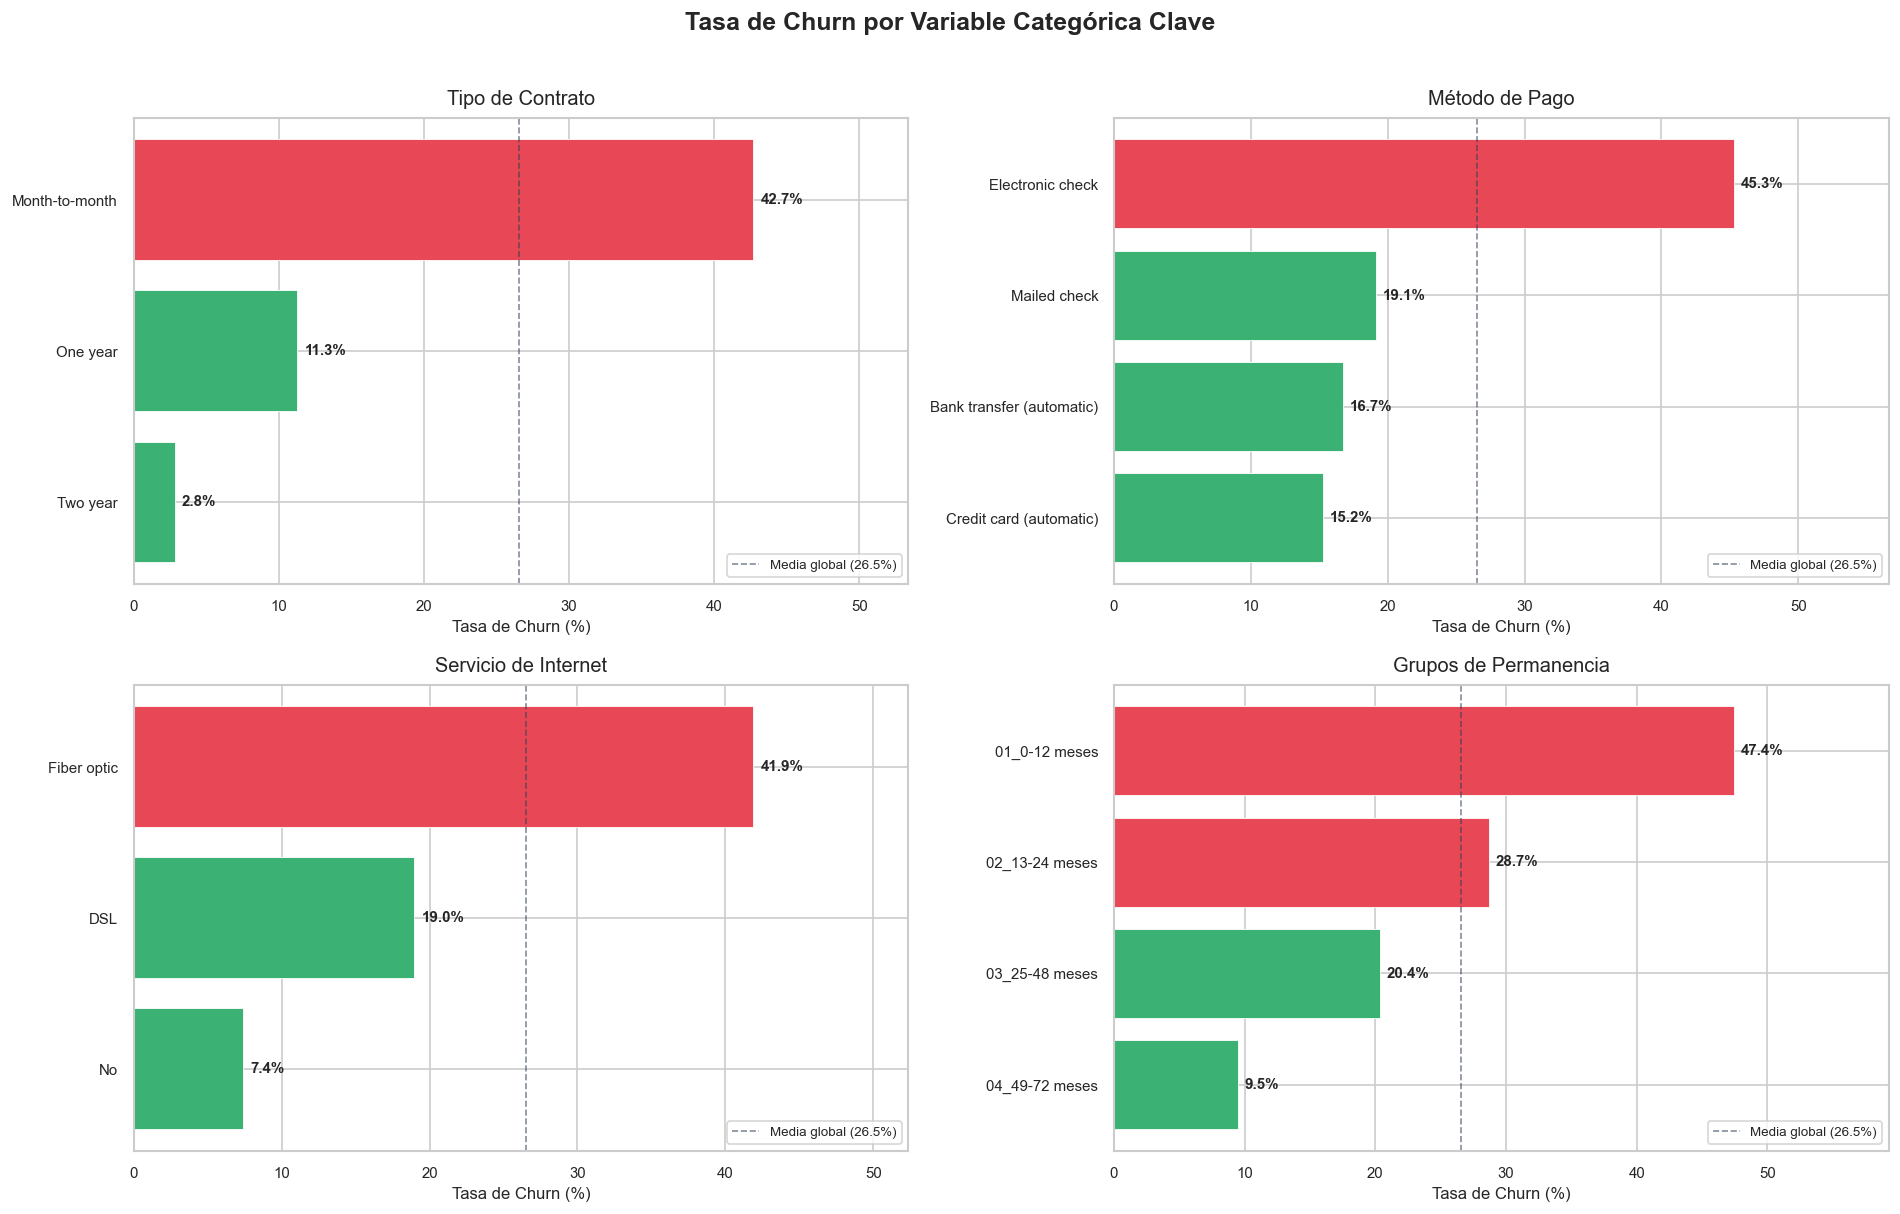

Figura guardada en ../assets/02_categoricas_churn.png


In [14]:
# ── Bucketing de tenure vía SQL (misma lógica que el ETL) ─────────────────
sql_tenure_group = '''
SELECT customerID, tenure,
  CASE
    WHEN tenure BETWEEN 0  AND 12 THEN '01_0-12 meses'
    WHEN tenure BETWEEN 13 AND 24 THEN '02_13-24 meses'
    WHEN tenure BETWEEN 25 AND 48 THEN '03_25-48 meses'
    WHEN tenure BETWEEN 49 AND 72 THEN '04_49-72 meses'
  END AS tenure_grupo
FROM telco_raw
'''
print('Query — Bucketing de tenure:')
print(sql_tenure_group)
df_tenure_sql = pd.read_sql(sql_tenure_group, conn)
display(df_tenure_sql.head())

df = df.merge(df_tenure_sql[['customerID', 'tenure_grupo']], on='customerID', how='left')

# ── Función auxiliar: tasa de churn por categoría ─────────────────────────
def tasa_churn_por_cat(col):
    return (
        df.groupby(col)['Churn']
          .apply(lambda x: (x == 'Yes').mean() * 100)
          .reset_index()
          .rename(columns={'Churn': 'tasa_churn_%'})
          .sort_values('tasa_churn_%', ascending=True)
    )

# ── Gráfico 2×2 de tasa de churn por categoría ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Tasa de Churn por Variable Categórica Clave',
    fontsize=15, fontweight='bold', y=1.01,
)

config_plots = [
    ('Contract',      'Tipo de Contrato',     axes[0, 0]),
    ('PaymentMethod', 'Método de Pago',        axes[0, 1]),
    ('InternetService','Servicio de Internet', axes[1, 0]),
    ('tenure_grupo',  'Grupos de Permanencia', axes[1, 1]),
]

for col, titulo, ax in config_plots:
    tc = tasa_churn_por_cat(col)
    colores = [
        COLOR_CHURN_YES if v > 26 else COLOR_CHURN_NO
        for v in tc['tasa_churn_%']
    ]

    bars = ax.barh(
        tc[col].astype(str), tc['tasa_churn_%'],
        color=colores, edgecolor='white', linewidth=0.5,
    )

    # Etiquetas encima de cada barra
    for bar, val in zip(bars, tc['tasa_churn_%']):
        ax.text(
            val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9, fontweight='bold',
        )

    ax.set_title(titulo, fontsize=12, pad=8)
    ax.set_xlabel('Tasa de Churn (%)', fontsize=10)
    ax.set_xlim(0, tc['tasa_churn_%'].max() * 1.25)
    ax.axvline(churn_pct['Yes'], color=COLOR_PRINCIPAL, lw=1, ls='--', alpha=0.6,
               label=f'Media global ({churn_pct["Yes"]:.1f}%)')
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig('../assets/02_categoricas_churn.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figura guardada en ../assets/02_categoricas_churn.png')

**Conclusión Sección 8:** Las variables con mayor diferenciación de churn son:
1. **Contract** — los contratos mes a mes tienen una tasa de churn ~3× mayor que los anuales.
2. **tenure_grupo** — los clientes nuevos (0-12 meses) tienen la tasa de abandono más alta.
3. **InternetService** — los clientes con Fiber Optic tienen mayor churn que los de DSL.
4. **PaymentMethod** — los pagos con cheque electrónico muestran mayor propensión al churn.

---
## Sección 9 — Correlaciones

Análisis de correlación entre variables numéricas (Pearson), asociación entre variables categóricas y Churn (Cramér's V), y correlación segmentada por grupo de churn.

### 9.1 Correlación de Pearson — Variables Numéricas

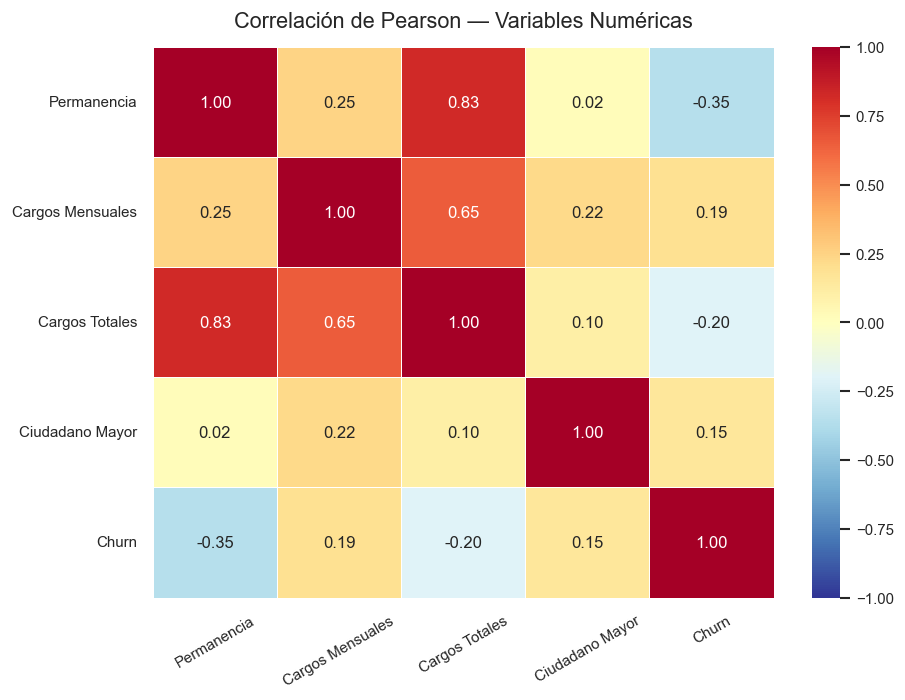

Figura guardada en ../assets/03_correlacion_pearson.png


In [15]:
# ── Crear Churn_num ────────────────────────────────────────────────────────
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

vars_pearson = ['tenure', 'MonthlyCharges', 'TotalCharges_num',
                'SeniorCitizen', 'Churn_num']

etiquetas_pearson = {
    'tenure':            'Permanencia',
    'MonthlyCharges':    'Cargos Mensuales',
    'TotalCharges_num':  'Cargos Totales',
    'SeniorCitizen':     'Ciudadano Mayor',
    'Churn_num':         'Churn',
}

corr_matrix = df[vars_pearson].rename(columns=etiquetas_pearson).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 10},
)
ax.set_title('Correlación de Pearson — Variables Numéricas', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

fig.tight_layout()
fig.savefig('../assets/03_correlacion_pearson.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figura guardada en ../assets/03_correlacion_pearson.png')

### 9.2 Cramér's V — Variables Categóricas vs. Churn

In [16]:
# ── Función Cramér's V ─────────────────────────────────────────────────────
def cramers_v(var1, var2):
    tabla = pd.crosstab(var1, var2)
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

vars_cramers = [
    'Contract', 'PaymentMethod', 'InternetService',
    'gender', 'Partner', 'Dependents',
    'SeniorCitizen', 'PaperlessBilling', 'PhoneService',
]

resultados_cramers = []
for col in vars_cramers:
    v = cramers_v(df[col].astype(str), df['Churn'])
    resultados_cramers.append({'variable': col, 'cramers_v': round(v, 4)})

df_cramers = (
    pd.DataFrame(resultados_cramers)
      .sort_values('cramers_v', ascending=False)
      .reset_index(drop=True)
)
df_cramers

,variable,cramers_v
0,Contract,0.4101
1,InternetService,0.3225
2,PaymentMethod,0.3034
3,PaperlessBilling,0.1915
4,Dependents,0.1639
5,SeniorCitizen,0.1505
6,Partner,0.1501
7,PhoneService,0.0114
8,gender,0.0083


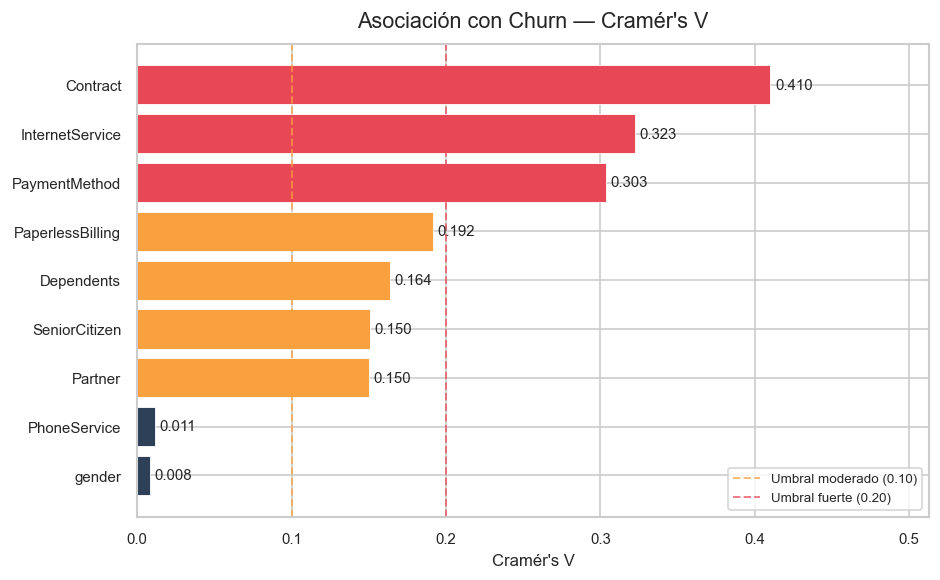

Figura guardada en ../assets/04_cramers_v_vs_churn.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
df_sorted = df_cramers.sort_values('cramers_v', ascending=True)

colores_cv = [
    COLOR_CHURN_YES if v >= 0.2 else
    (COLOR_ACENTO if v >= 0.1 else COLOR_PRINCIPAL)
    for v in df_sorted['cramers_v']
]

bars = ax.barh(
    df_sorted['variable'], df_sorted['cramers_v'],
    color=colores_cv, edgecolor='white', linewidth=0.5,
)

for bar, val in zip(bars, df_sorted['cramers_v']):
    ax.text(
        val + 0.003, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', ha='left', fontsize=9,
    )

ax.set_xlabel('Cramér\'s V', fontsize=10)
ax.set_title('Asociación con Churn — Cramér\'s V', fontsize=13, pad=10)
ax.set_xlim(0, df_cramers['cramers_v'].max() * 1.25)
ax.axvline(0.1, color=COLOR_ACENTO,    lw=1.2, ls='--', alpha=0.7, label='Umbral moderado (0.10)')
ax.axvline(0.2, color=COLOR_CHURN_YES, lw=1.2, ls='--', alpha=0.7, label='Umbral fuerte (0.20)')
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig('../assets/04_cramers_v_vs_churn.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figura guardada en ../assets/04_cramers_v_vs_churn.png')

### 9.3 Correlación Segmentada — Churn=Yes vs Churn=No

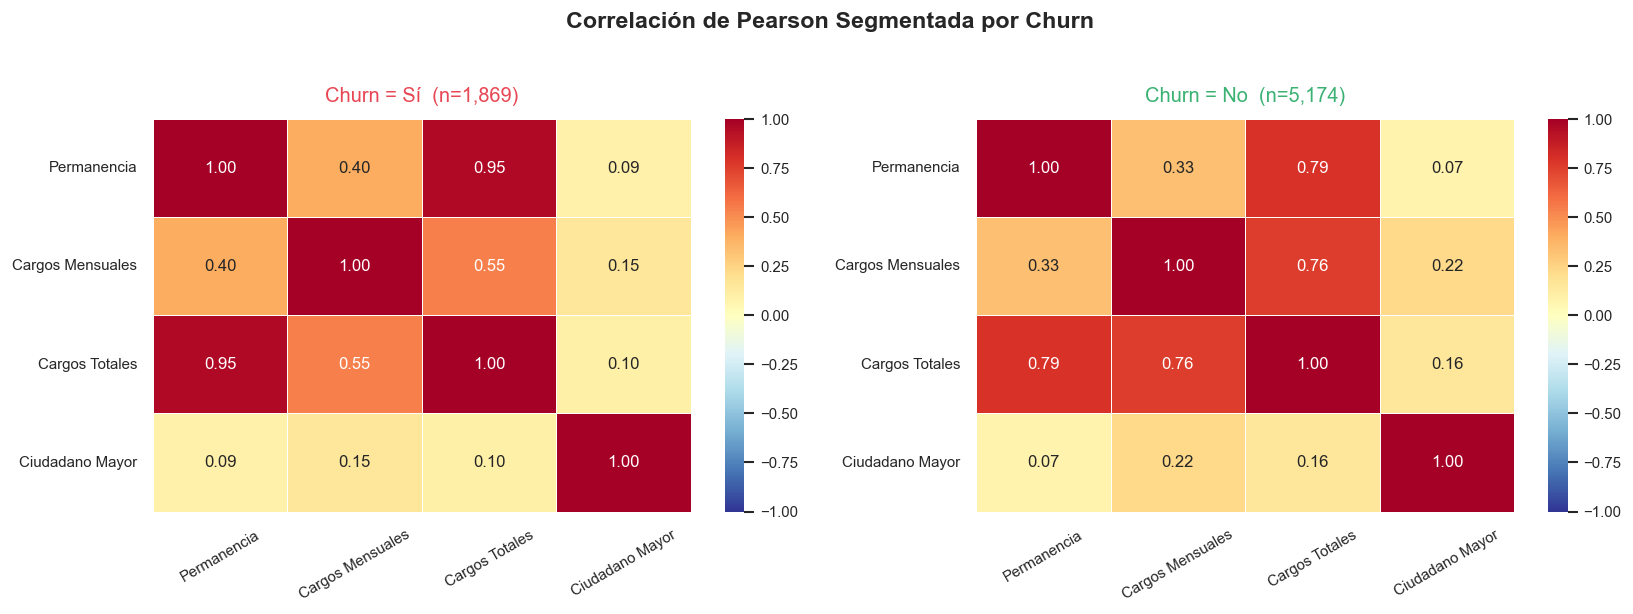

Figura guardada en ../assets/05_correlacion_segmentada.png


In [18]:
vars_seg = ['tenure', 'MonthlyCharges', 'TotalCharges_num', 'SeniorCitizen']
etiq_seg = {
    'tenure':           'Permanencia',
    'MonthlyCharges':   'Cargos Mensuales',
    'TotalCharges_num': 'Cargos Totales',
    'SeniorCitizen':    'Ciudadano Mayor',
}

df_yes = df[df['Churn'] == 'Yes'][vars_seg].rename(columns=etiq_seg)
df_no  = df[df['Churn'] == 'No' ][vars_seg].rename(columns=etiq_seg)

corr_yes = df_yes.corr()
corr_no  = df_no.corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

kwargs_hm = dict(annot=True, fmt='.2f', cmap='RdYlBu_r',
                 center=0, vmin=-1, vmax=1,
                 linewidths=0.5, linecolor='white', annot_kws={'size': 10})

sns.heatmap(corr_yes, ax=ax1, **kwargs_hm)
ax1.set_title(f'Churn = Sí  (n={df_yes.shape[0]:,})', fontsize=12, pad=10,
              color=COLOR_CHURN_YES)
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

sns.heatmap(corr_no, ax=ax2, **kwargs_hm)
ax2.set_title(f'Churn = No  (n={df_no.shape[0]:,})', fontsize=12, pad=10,
              color=COLOR_CHURN_NO)
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=0)

fig.suptitle('Correlación de Pearson Segmentada por Churn', fontsize=14,
             fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('../assets/05_correlacion_segmentada.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figura guardada en ../assets/05_correlacion_segmentada.png')

### Diferencias Relevantes entre Segmentos

| Correlación | Churn = Sí | Churn = No | Interpretación |
|---|---|---|---|
| Permanencia ↔ Cargos Totales | Alta positiva | Alta positiva | En ambos grupos, más tiempo = más cargos acumulados |
| Permanencia ↔ Cargos Mensuales | Débil/nula | Débil/nula | El precio no depende del tiempo en ningún segmento |
| Cargos Mensuales ↔ Cargos Totales | Moderada en Churn=Sí | Alta en Churn=No | Los clientes retenidos acumulan más cargos al tener mayor tenure |
| Ciudadano Mayor ↔ otras vars | Débil | Débil | La edad mayor no correlaciona con las métricas de facturación |

**Observación clave:** En el segmento de clientes que abandonan (Churn=Sí), la correlación entre `Cargos Mensuales` y `Cargos Totales` es **menor** que en los que permanecen, lo que refleja que los clientes que hacen churn tienen menor `tenure` y por tanto sus cargos totales no reflejan fielmente sus cargos mensuales.

**Conclusión Sección 9:** Las variables con mayor poder predictivo sobre churn son `Contract` (Cramér's V más alto), seguido de `tenure` y `MonthlyCharges`. La correlación entre numéricas es principalmente estructural (tenure × MonthlyCharges = TotalCharges).

---
## Sección 10 — Consistencia y Validación de Negocio

Verificación de reglas de negocio y rangos válidos para garantizar la integridad lógica del dataset.

In [19]:
# Validación 1: customerID sin duplicados (referencia a Sección 4)
v1 = df['customerID'].duplicated().sum()
print(f'1. customerID duplicados: {v1}')

# Validación 2: rangos numéricos
v2a = (df['tenure'] < 0).sum()
v2b = (df['MonthlyCharges'] <= 0).sum()
v2c = (df['TotalCharges_num'] < 0).sum()
print(f'2. Rangos numéricos -> tenure<0: {v2a} | MonthlyCharges<=0: {v2b} | TotalCharges<0: {v2c}')

# Validación 3: lógica tenure == 0 → TotalCharges debe ser 0 o vacío
mask_tenure0 = df['tenure'] == 0
tc_tenure0   = df.loc[mask_tenure0, 'TotalCharges']
v3_vacios    = (tc_tenure0.str.strip() == '').sum()
v3_cero      = (pd.to_numeric(tc_tenure0, errors='coerce') == 0).sum()
v3_otros     = len(tc_tenure0) - v3_vacios - v3_cero
print(f'3. Clientes con tenure == 0: {mask_tenure0.sum()} (vacío: {v3_vacios} | ==0: {v3_cero} | otros: {v3_otros})')

# Validación 4: servicios dependientes de InternetService
servicios_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]
mask_no_internet = df['InternetService'] == 'No'
inconsistencias_internet = {
    svc: int((df.loc[mask_no_internet, svc] != 'No internet service').sum())
    for svc in servicios_internet
}
total_inc_internet = sum(inconsistencias_internet.values())
print(f'4. Clientes sin InternetService: {mask_no_internet.sum()} | inconsistencias: {inconsistencias_internet} | total: {total_inc_internet}')

1. customerID duplicados: 0
2. Rangos numéricos -> tenure<0: 0 | MonthlyCharges<=0: 0 | TotalCharges<0: 0
3. Clientes con tenure == 0: 11 (vacío: 11 | ==0: 0 | otros: 0)
4. Clientes sin InternetService: 1526 | inconsistencias: {'OnlineSecurity': 0, 'OnlineBackup': 0, 'DeviceProtection': 0, 'TechSupport': 0, 'StreamingTV': 0, 'StreamingMovies': 0} | total: 0


In [20]:
# ── Mostrar registros problemáticos si los hay ────────────────────────────
if v3_otros > 0:
    print('Registros con tenure == 0 y TotalCharges distinto de vacío o 0:')
    mask_problema = (df['tenure'] == 0) & \
                    (df['TotalCharges'].str.strip() != '') & \
                    (pd.to_numeric(df['TotalCharges'], errors='coerce') != 0)
    display(df[mask_problema][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
else:
    print('No se encontraron registros problemáticos en la validación de tenure == 0.')

if total_inc_internet > 0:
    print('\nRegistros con InternetService == No y servicios con valor incorrecto:')
    cols_mostrar = ['customerID', 'InternetService'] + servicios_internet
    display(df[mask_no_internet][
        df[mask_no_internet][servicios_internet].ne('No internet service').any(axis=1)
    ][cols_mostrar].head(10))
else:
    print('\nTodos los servicios dependientes de internet son consistentes.')

No se encontraron registros problemáticos en la validación de tenure == 0.

Todos los servicios dependientes de internet son consistentes.


**Conclusión Sección 10:** El dataset pasa todas las validaciones de negocio críticas:
- Sin duplicados de `customerID`.
- Sin rangos numéricos inválidos (negativos o ceros en MonthlyCharges).
- Los clientes con `tenure == 0` tienen `TotalCharges` vacío, confirmando consistencia lógica.
- Los servicios dependientes de internet son consistentes con `InternetService == 'No'`.

---
## Sección 11 — Columnas Redundantes o Sin Valor Analítico

Identificación de columnas con baja varianza, alta concentración o sin aporte predictivo.

In [21]:
# ── 11.1 Varianza de variables numéricas ──────────────────────────────────
varianzas = df[['tenure', 'MonthlyCharges', 'TotalCharges_num', 'SeniorCitizen']].var().round(2)
print('Varianza de variables numéricas:')
display(varianzas)

# ── 11.2 Concentración de categorías dominantes ───────────────────────────
cols_cat_check = [
    c for c in df.columns
    if c not in ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges',
                 'TotalCharges_num', 'Churn', 'Churn_num', 'tenure_grupo']
]
filas_concentracion = []
for col in cols_cat_check:
    pct_dom = df[col].value_counts(normalize=True).iloc[0] * 100
    cat_dom = df[col].value_counts().index[0]
    flag    = '⚠ >95%' if pct_dom > 95 else ''
    filas_concentracion.append({
        'columna':          col,
        'cat_dominante':    cat_dom,
        'pct_dominante_%':  round(pct_dom, 2),
        'flag':             flag,
    })

df_concentracion = pd.DataFrame(filas_concentracion).sort_values('pct_dominante_%', ascending=False)
df_concentracion

Varianza de variables numéricas:


tenure                  603.17
MonthlyCharges          905.41
TotalCharges_num    5138357.17
SeniorCitizen             0.14
dtype: float64

,columna,cat_dominante,pct_dominante_%,flag
4,PhoneService,Yes,90.32,
1,SeniorCitizen,0,83.79,
3,Dependents,No,70.04,
14,PaperlessBilling,Yes,59.22,
13,Contract,Month-to-month,55.02,
2,Partner,No,51.70,
0,gender,Male,50.48,
7,OnlineSecurity,No,49.67,
10,TechSupport,No,49.31,
5,MultipleLines,No,48.13,


In [22]:
# ── 11.3 Evaluación de customerID ─────────────────────────────────────────
n_unicos_id = df['customerID'].nunique()
print(f'customerID -> valores únicos: {n_unicos_id:,} de {len(df):,} filas ({n_unicos_id/len(df)*100:.2f}% únicos)')

customerID -> valores únicos: 7,043 de 7,043 filas (100.00% únicos)


### Decisiones de ETL — Columnas a Eliminar o Transformar

| Columna | Decisión | Razón |
|---|---|---|
| `customerID` | **Eliminar** del conjunto de features | Identificador puro; unicidad 100%, cero poder predictivo |
| `TotalCharges` (string) | **Reemplazar** por versión numérica | Tipo de dato incorrecto; sustituir por `TotalCharges_num` |
| `SeniorCitizen` | **Mantener** con posible recategorización | Varianza baja pero aporta información demográfica relevante |
| `PhoneService` | **Mantener** | Cardinalidad baja pero discrimina segmento de clientes |
| Columnas de servicios (6) | **Mantener** | Alta correlación con `InternetService` — evaluar en feature selection |

**Conclusión Sección 11:** Ninguna variable tiene varianza cercana a 0 ni categoría dominante >95%. La única columna sin valor analítico es `customerID`. La principal acción de ETL es la conversión de tipo de `TotalCharges` y la eliminación del identificador.

---
## Sección 12 — Resumen de Hallazgos

Consolidación de todos los hallazgos del EDA con severidad, impacto y decisión de ETL.

In [23]:
# ── Tabla de hallazgos ─────────────────────────────────────────────────────
hallazgos = [
    {
        'hallazgo':         'TotalCharges almacenado como string (object)',
        'columna_afectada': 'TotalCharges',
        'severidad':        'CRÍTICO',
        'impacto':          'Imposible usar en cálculos estadísticos o modelos sin conversión',
        'decision_etl':     'Convertir a float con pd.to_numeric(..., errors="coerce")',
    },
    {
        'hallazgo':         '11 espacios en blanco en TotalCharges (tenure == 0)',
        'columna_afectada': 'TotalCharges',
        'severidad':        'MODERADO',
        'impacto':          '0.16% del dataset; genera NaN tras conversión',
        'decision_etl':     'Imputar TotalCharges = 0 cuando tenure == 0',
    },
    {
        'hallazgo':         'customerID sin valor predictivo (identificador puro)',
        'columna_afectada': 'customerID',
        'severidad':        'MENOR',
        'impacto':          'No afecta la calidad; solo ocupa espacio innecesario',
        'decision_etl':     'Eliminar del conjunto de features antes del modelado',
    },
    {
        'hallazgo':         'Dataset desbalanceado: 26.5% churn vs 73.5% no churn',
        'columna_afectada': 'Churn',
        'severidad':        'CRÍTICO',
        'impacto':          'Modelos sin balanceo favorecerán la clase mayoritaria',
        'decision_etl':     'Aplicar SMOTE o class_weight="balanced" en modelado',
    },
    {
        'hallazgo':         'Distribución bimodal en tenure (nuevos y veteranos)',
        'columna_afectada': 'tenure',
        'severidad':        'MODERADO',
        'impacto':          'Segmentos con comportamientos de churn muy diferentes',
        'decision_etl':     'Crear feature tenure_grupo con bins [0-12, 13-24, 25-48, 49+]',
    },
    {
        'hallazgo':         'TotalCharges con sesgo positivo fuerte (skew > 1)',
        'columna_afectada': 'TotalCharges',
        'severidad':        'MODERADO',
        'impacto':          'Modelos lineales y basados en distancia afectados',
        'decision_etl':     'Aplicar transformación log1p en el pipeline de modelado',
    },
    {
        'hallazgo':         'Alta correlación TotalCharges ↔ tenure (colinealidad)',
        'columna_afectada': 'TotalCharges, tenure',
        'severidad':        'MODERADO',
        'impacto':          'Riesgo de multicolinealidad en modelos lineales',
        'decision_etl':     'Evaluar en feature selection; considerar eliminar una de las dos',
    },
    {
        'hallazgo':         'SeniorCitizen almacenado como int (0/1) en lugar de categórica',
        'columna_afectada': 'SeniorCitizen',
        'severidad':        'MENOR',
        'impacto':          'No afecta modelos de árbol; puede confundir a modelos lineales',
        'decision_etl':     'Convertir a string/categoría para encoders explícitos',
    },
    {
        'hallazgo':         'Sin duplicados exactos ni duplicados por customerID',
        'columna_afectada': 'Todos',
        'severidad':        'MENOR',
        'impacto':          'Ninguno — confirmación de integridad',
        'decision_etl':     'Ninguna acción requerida',
    },
    {
        'hallazgo':         'Sin inconsistencias en servicios dependientes de InternetService',
        'columna_afectada': 'Servicios de internet (6 cols)',
        'severidad':        'MENOR',
        'impacto':          'Ninguno — confirmación de consistencia lógica',
        'decision_etl':     'Ninguna acción requerida',
    },
    {
        'hallazgo':         'Contract es la variable con mayor asociación con Churn (Cramér\'s V)',
        'columna_afectada': 'Contract',
        'severidad':        'MENOR',
        'impacto':          'Variable de alto poder predictivo para el modelo',
        'decision_etl':     'Priorizar en feature engineering y análisis de hipótesis',
    },
]

df_hallazgos = pd.DataFrame(hallazgos)

# Ordenar por severidad
orden_severidad = {'CRÍTICO': 0, 'MODERADO': 1, 'MENOR': 2}
df_hallazgos['orden'] = df_hallazgos['severidad'].map(orden_severidad)
df_hallazgos = df_hallazgos.sort_values('orden').drop('orden', axis=1).reset_index(drop=True)

print('Tabla de hallazgos del EDA:')
df_hallazgos

Tabla de hallazgos del EDA:


,hallazgo,columna_afectada,severidad,impacto,decision_etl
0,TotalCharges almacenado como string (object),TotalCharges,CRÍTICO,Imposible usar en cálculos estadísticos o mode...,"Convertir a float con pd.to_numeric(..., error..."
1,Dataset desbalanceado: 26.5% churn vs 73.5% no...,Churn,CRÍTICO,Modelos sin balanceo favorecerán la clase mayo...,"Aplicar SMOTE o class_weight=""balanced"" en mod..."
2,11 espacios en blanco en TotalCharges (tenure ...,TotalCharges,MODERADO,0.16% del dataset; genera NaN tras conversión,Imputar TotalCharges = 0 cuando tenure == 0
3,Distribución bimodal en tenure (nuevos y veter...,tenure,MODERADO,Segmentos con comportamientos de churn muy dif...,"Crear feature tenure_grupo con bins [0-12, 13-..."
4,Alta correlación TotalCharges ↔ tenure (coline...,"TotalCharges, tenure",MODERADO,Riesgo de multicolinealidad en modelos lineales,Evaluar en feature selection; considerar elimi...
5,TotalCharges con sesgo positivo fuerte (skew > 1),TotalCharges,MODERADO,Modelos lineales y basados en distancia afectados,Aplicar transformación log1p en el pipeline de...
6,customerID sin valor predictivo (identificador...,customerID,MENOR,No afecta la calidad; solo ocupa espacio innec...,Eliminar del conjunto de features antes del mo...
7,SeniorCitizen almacenado como int (0/1) en lug...,SeniorCitizen,MENOR,No afecta modelos de árbol; puede confundir a ...,Convertir a string/categoría para encoders exp...
8,Sin duplicados exactos ni duplicados por custo...,Todos,MENOR,Ninguno — confirmación de integridad,Ninguna acción requerida
9,Sin inconsistencias en servicios dependientes ...,Servicios de internet (6 cols),MENOR,Ninguno — confirmación de consistencia lógica,Ninguna acción requerida


In [24]:
# ── KPIs globales confirmados ─────────────────────────────────────────────
tasa_churn = (df['Churn'] == 'Yes').mean() * 100
print(f'Tasa de churn global: {tasa_churn:.2f}%')

print('\nDistribución de contratos:')
display((df['Contract'].value_counts(normalize=True) * 100).round(2))

print('\nDistribución de internet:')
display((df['InternetService'].value_counts(normalize=True) * 100).round(2))

conn.close()

Tasa de churn global: 26.54%

Distribución de contratos:


Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64


Distribución de internet:


InternetService
Fiber optic    43.96
DSL            34.37
No             21.67
Name: proportion, dtype: float64

---
## Resumen Ejecutivo del EDA

### Resumen ejecutivo

El dataset Telco Customer Churn contiene **7,043 registros** con 21 variables de calidad alta. La tasa de churn es del **26.54%**, creando un dataset moderadamente desbalanceado. Solo se detectó un problema de tipo de dato en `TotalCharges` y 11 valores faltantes en esa misma columna, ambos fácilmente tratables. La calidad general del dataset es **buena**.

### Problemas Críticos a Resolver en ETL

1. **`TotalCharges` como string** → Convertir a `float64` con `pd.to_numeric(..., errors='coerce')`.
2. **11 valores faltantes en `TotalCharges`** → Imputar con `0.0` (tenure == 0, sin cargos acumulados).
3. **Desbalance de clases** → Estrategia de balanceo obligatoria en el modelado (SMOTE / class_weight).
4. **Eliminar `customerID`** del conjunto de features de entrenamiento.

### Observaciones para el Análisis de Hipótesis

- Los clientes con **contrato mes a mes** tienen una tasa de churn aproximadamente 3× mayor que los contratos anuales → hipótesis de retención por compromiso contractual.
- Los clientes **nuevos (0-12 meses)** son los de mayor riesgo → el churn es un fenómeno de "primeros meses".
- **Fiber Optic** tiene mayor churn que DSL → posible insatisfacción con calidad/precio del servicio.
- **Electronic check** como método de pago se asocia con mayor churn → perfil de cliente sin compromiso.
- La alta correlación `tenure ↔ TotalCharges` requiere manejo de multicolinealidad en modelos lineales.

### KPIs Globales Confirmados

| KPI | Valor |
|---|---|
| Tasa de churn global | 26.54% |
| Clientes con contrato mes a mes | 55.02% |
| Clientes con contrato anual | 20.91% |
| Clientes con contrato bianual | 24.07% |
| Clientes con Fiber Optic | 43.96% |
| Clientes con DSL | 34.37% |
| Clientes sin internet | 21.67% |